# CodeMind IDE — Bug Classifier Training

Fine-tunes `microsoft/codebert-base` on synthetic bug data.

**Classes:**
- 0: clean
- 1: sql_injection  
- 2: division_by_zero
- 3: null_reference
- 4: xss

**Requirements:**
```
pip install transformers datasets scikit-learn pandas torch
```

**Run data collection first:**
```
python backend/data/training/data_collector.py
```

In [1]:
# Install dependencies if needed
# !pip install transformers datasets scikit-learn pandas torch

In [2]:
import pandas as pd
import numpy as np
import torch
import os
from pathlib import Path

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU — training on CPU (will be slower but works fine)')

Using device: cuda
GPU: Tesla T4


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# ── Load dataset ──────────────────────────────────────────────
DATA_DIR = Path('/content/drive/MyDrive/training')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train: {len(train_df)} samples')
print(f'Val:   {len(val_df)} samples')
print(f'Test:  {len(test_df)} samples')
print()
print('Class distribution (train):')
print(train_df['bug_class'].value_counts())

Train: 112 samples
Val:   24 samples
Test:  24 samples

Class distribution (train):
bug_class
clean            86
sql_injection    26
Name: count, dtype: int64


In [11]:
from transformers import AutoTokenizer

MODEL_NAME = 'microsoft/codebert-base'
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded ✓')

Loading tokenizer: microsoft/codebert-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Tokenizer loaded ✓


In [12]:
from torch.utils.data import Dataset

class CodeDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.codes     = df['code'].fillna('').tolist()
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self):
        return len(self.codes)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.codes[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = CodeDataset(train_df, tokenizer)
val_dataset   = CodeDataset(val_df,   tokenizer)
test_dataset  = CodeDataset(test_df,  tokenizer)

print(f'Train dataset: {len(train_dataset)} samples')
print(f'Val dataset:   {len(val_dataset)} samples')
print(f'Test dataset:  {len(test_dataset)} samples')

Train dataset: 112 samples
Val dataset:   24 samples
Test dataset:  24 samples


In [13]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS = 5
LABEL_NAMES = ['clean', 'sql_injection', 'division_by_zero', 'null_reference', 'xss']

print(f'Loading model: {MODEL_NAME}')
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={i: n for i, n in enumerate(LABEL_NAMES)},
    label2id={n: i for i, n in enumerate(LABEL_NAMES)},
)
model = model.to(device)
print(f'Model loaded ✓  Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loading model: microsoft/codebert-base


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/codebert-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded ✓  Parameters: 124,649,477


In [ ]:
import torch
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }


SAVE_DIR = '/content/drive/MyDrive/model'

training_args = TrainingArguments(
    output_dir=SAVE_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=10,
    report_to='none',   # disable wandb
    fp16=torch.cuda.is_available(),  # use fp16 if GPU available
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print('Training configuration:')
print(f'  Epochs:     {training_args.num_train_epochs}')
print(f'  Batch size: {training_args.per_device_train_batch_size}')
print(f'  LR:         {training_args.learning_rate}')
print(f'  Device:     {device}')
print(f'  Save to:    {SAVE_DIR}')

Training configuration:
  Epochs:     3
  Batch size: 8
  LR:         2e-05
  Device:     cuda
  Save to:    /content/drive/MyDrive/model


In [19]:
import transformers
print(transformers.__version__)
from transformers import TrainingArguments
print(TrainingArguments.__init__.__code__.co_varnames)


5.0.0
('self', 'output_dir', 'do_train', 'do_eval', 'do_predict', 'eval_strategy', 'prediction_loss_only', 'per_device_train_batch_size', 'per_device_eval_batch_size', 'gradient_accumulation_steps', 'eval_accumulation_steps', 'eval_delay', 'torch_empty_cache_steps', 'learning_rate', 'weight_decay', 'adam_beta1', 'adam_beta2', 'adam_epsilon', 'max_grad_norm', 'num_train_epochs', 'max_steps', 'lr_scheduler_type', 'lr_scheduler_kwargs', 'warmup_ratio', 'warmup_steps', 'log_level', 'log_level_replica', 'log_on_each_node', 'logging_dir', 'logging_strategy', 'logging_first_step', 'logging_steps', 'logging_nan_inf_filter', 'save_strategy', 'save_steps', 'save_total_limit', 'enable_jit_checkpoint', 'save_on_each_node', 'save_only_model', 'restore_callback_states_from_checkpoint', 'use_cpu', 'seed', 'data_seed', 'bf16', 'fp16', 'bf16_full_eval', 'fp16_full_eval', 'tf32', 'local_rank', 'ddp_backend', 'debug', 'dataloader_drop_last', 'eval_steps', 'dataloader_num_workers', 'dataloader_prefetch_fa

In [21]:
# ── TRAIN ─────────────────────────────────────────────────────
print('Starting training...')
print('This takes ~10-30 minutes on CPU, ~3-5 minutes on GPU')
print()

trainer.train()
print('\n✅ Training complete!')

Starting training...
This takes ~10-30 minutes on CPU, ~3-5 minutes on GPU



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.562598,1.356852,0.708333,0.414634
2,1.352649,0.862590,0.708333,0.414634
3,0.659056,0.404312,0.708333,0.414634


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


✅ Training complete!


In [22]:
# ── EVALUATE on test set ──────────────────────────────────────
print('Evaluating on test set...')
predictions = trainer.predict(test_dataset)
preds  = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

acc    = accuracy_score(labels, preds)
f1     = f1_score(labels, preds, average='macro')

print(f'\n📊 Test Results:')
print(f'  Accuracy:  {acc:.4f} ({acc*100:.1f}%)')
print(f'  F1 Macro:  {f1:.4f}')
print()
print('Classification Report:')
print(classification_report(labels, preds, target_names=LABEL_NAMES))

Evaluating on test set...



📊 Test Results:
  Accuracy:  0.7083 (70.8%)
  F1 Macro:  0.4146

Classification Report:


ValueError: Number of classes, 2, does not match size of target_names, 5. Try specifying the labels parameter

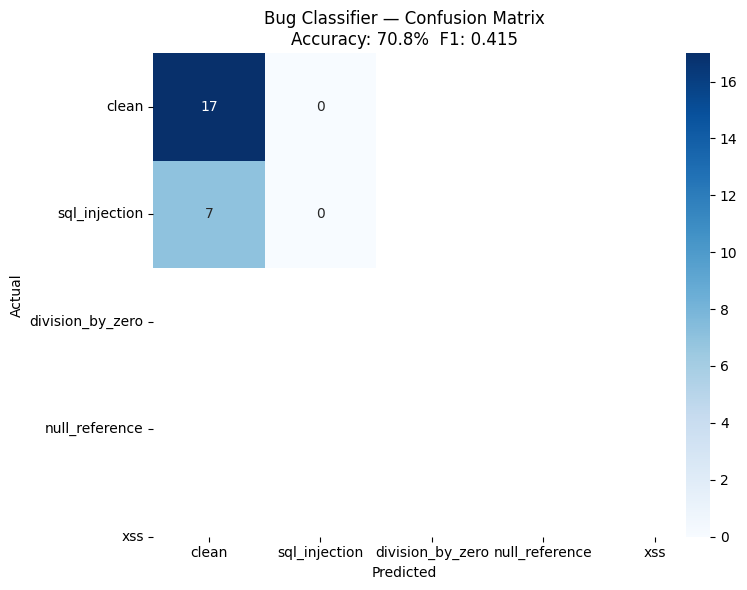

Confusion matrix saved ✓


In [24]:
# ── CONFUSION MATRIX ──────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title(f'Bug Classifier — Confusion Matrix\nAccuracy: {acc*100:.1f}%  F1: {f1:.3f}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved ✓')

In [25]:
# ── SAVE MODEL ────────────────────────────────────────────────
print(f'Saving model to {SAVE_DIR}...')
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Save metrics for the backend health endpoint
import json
metrics = {
    'accuracy':  round(float(acc), 4),
    'f1_macro':  round(float(f1),  4),
    'num_labels': NUM_LABELS,
    'label_names': LABEL_NAMES,
    'model_name': MODEL_NAME,
    'train_samples': len(train_df),
    'test_samples':  len(test_df),
}
with open(f'{SAVE_DIR}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'\n✅ Model saved!')
print(f'   Accuracy: {acc*100:.1f}%')
print(f'   F1 Macro: {f1:.3f}')
print(f'\nNext step: restart uvicorn — the bug classifier will load automatically')

Saving model to /content/drive/MyDrive/model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved!
   Accuracy: 70.8%
   F1 Macro: 0.415

Next step: restart uvicorn — the bug classifier will load automatically


In [26]:
# ── QUICK TEST ────────────────────────────────────────────────
# Test the saved model with a few examples

test_snippets = [
    # Should predict: sql_injection
    '''
def get_user(username):
    query = "SELECT * FROM users WHERE name = '" + username + "'"
    return db.execute(query)
''',
    # Should predict: division_by_zero
    '''
def average(numbers):
    total = sum(numbers)
    return total / len(numbers)
''',
    # Should predict: clean
    '''
def get_user(username):
    query = "SELECT * FROM users WHERE name = ?"
    return db.execute(query, (username,))
''',
]

print('Quick inference test:')
print('=' * 50)

model.eval()
for i, snippet in enumerate(test_snippets):
    inputs = tokenizer(
        snippet, return_tensors='pt',
        max_length=512, truncation=True, padding=True
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=1)[0]
        pred    = probs.argmax().item()
    
    print(f'Snippet {i+1}:')
    print(f'  Prediction: {LABEL_NAMES[pred]} ({probs[pred]*100:.1f}% confidence)')
    print(f'  All probs:  { {n: f"{probs[j]*100:.1f}%" for j,n in enumerate(LABEL_NAMES)} }')
    print()

Quick inference test:
Snippet 1:
  Prediction: clean (27.2% confidence)
  All probs:  {'clean': '27.2%', 'sql_injection': '19.8%', 'division_by_zero': '17.2%', 'null_reference': '15.9%', 'xss': '19.9%'}

Snippet 2:
  Prediction: clean (26.0% confidence)
  All probs:  {'clean': '26.0%', 'sql_injection': '21.1%', 'division_by_zero': '17.6%', 'null_reference': '15.4%', 'xss': '19.8%'}

Snippet 3:
  Prediction: clean (27.3% confidence)
  All probs:  {'clean': '27.3%', 'sql_injection': '19.8%', 'division_by_zero': '17.3%', 'null_reference': '15.9%', 'xss': '19.7%'}

